In [1]:
import sys
sys.path.append('../')
import time

import numpy as np
import matplotlib.pyplot as plt

import epics
from siriuspy.devices import CAXCtrl
from caxscripts.h5file import HDF5File

In [2]:
CAX = CAXCtrl()

# study tx and photocolector

In [3]:
CAX.mirror.photocurrent_signal

0.0

In [9]:
PVPC = 'CAX:A:RIO01:9215A:ai0'

In [10]:
epics.caget(PVPC)

0.0

In [ ]:
tx0 = CAX.mirror.tx_pos
tx0

-3.8500000000000014e-05

In [16]:
with open('initial_state_mirror_tx.txt','w') as f:
    f.write(f'tx0: {tx0}')

In [153]:
STEP = 0.005

In [ ]:
CAX.mirror.tx_pos -= STEP
CAX.mirror.tx_pos, CAX.mirror.photocurrent_signal


(-0.10348, -0.04757485166192055)

In [ ]:
CAX.mirror.tx_pos

0.00062825

Anotações:

- diminuindo a posição Tx do espelho, o feixe deixou de incidir e formar imagem para tx=-0.483718
- reapareceu para tx=-0.483718
- ainda havia feixe sobre espelho
- perdeu-se por completo em tx=-0.93377425
- reapareceu para tx=-0.93377425

In [ ]:
CAX.mirror.ry_pos

0.3512205

# scan

In [6]:
def current_parameters():
    return {
        'slit1': {
            'top': CAX.slit_A1.top_pos,
            'bottom': CAX.slit_A1.bottom_pos,
            'left': CAX.slit_A1.left_pos,
            'right': CAX.slit_A1.right_pos
        },
        'dvf1': CAX.dvf_A1.acquisition_time,
        'dvf2': {
            'z_pos': CAX.dvf_B1.z_pos
        },
        'mirror': {
            'ry': CAX.mirror.ry_pos,
            'tx': CAX.mirror.tx_pos,
            'y1': CAX.mirror.y1_pos,
            'y2': CAX.mirror.y2_pos,
            'y3': CAX.mirror.y3_pos,
            'photocollector': CAX.mirror.photocurrent_signal
        }
    }

def move_all(top, bottom, left, right):
    CAX.slit_A1.move_top(value=top)
    CAX.slit_A1.move_bottom(value=bottom)
    CAX.slit_A1.move_left(value=left)
    CAX.slit_A1.move_right(value=right)

def open_all_slits():
    move_all(top=19.7-0.04,
             bottom=35.8,
             left=43.6-0.04,
             right=47.2)

In [7]:
local_time = time.localtime()
formatted_time = time.strftime("%Y%m%d-%H%M%S", local_time)
formatted_date = time.strftime("%Y%m%d", local_time)

formatted_time, formatted_date

('20250903-100111', '20250903')

In [8]:
parameters0 = current_parameters()

with open(f'initial_state_{formatted_time}.txt','w') as f:
    f.write(str(parameters0))

print(parameters0)

{'slit1': {'top': 16.46, 'bottom': 34.6, 'left': 42.893359375, 'right': 46.866640625}, 'dvf1': 0.5, 'dvf2': {'z_pos': None}, 'mirror': {'ry': 0.3512205, 'tx': -0.359893, 'y1': -0.5017925, 'y2': 1.1943553125, 'y3': -0.2924078125, 'photocollector': -0.05152083933353424}}


In [9]:
amplitude_tx = 0.80320475 - -1.00502125
amplitude_tx

1.8082259999999999

In [10]:
open_all_slits()

tests

In [4]:
STEP = 0.01

In [82]:
tx0 = CAX.mirror.tx_pos

In [34]:
CAX.mirror.tx_pos -= 0.01
CAX.mirror.tx_pos

-0.9899717499999999

In [94]:
CAX.mirror.tx_pos

0.80320475

In [160]:
CAX.mirror.photocurrent_signal

0.0

In [66]:
open_all_slits()

In [26]:
CAX.dvf_A1.acquisition_status

1

In [7]:
CAX.dvf_A1.cmd_acquire_on()

False

initialization file

In [57]:
filename = f'scan_tx_dvf_pc_{formatted_date}.h5'
filedir = f"/home/ids/data/{formatted_date}-Mirror-Tx-PC"

In [ ]:
file = HDF5File(filename=filename,filedir=filedir)

file.save_metadata(metadata_dict={
    'tx': CAX.mirror.tx_pos,
    'photocollector': CAX.mirror.photocurrent_signal
})

loop

In [36]:
tx0 = CAX.mirror.tx_pos

In [37]:
steps1 = np.linspace(0, amplitude_tx, 101)[1:]
steps2 = steps1.copy()[::-1][1:]
steps = np.hstack([steps1,steps2])

In [38]:
MAXERRORCOUNT = 5

In [39]:
def get_image(dvf):

    count = 0
    while count < MAXERRORCOUNT:
        try:
            if not dvf.acquisition_status:
                dvf.cmd_acquire_on()
            return dvf.image
        except Exception as err:
            print(f" WARNING. When trying to fetch image from DVF1: {err} ")
            time.sleep(2)
            count += 1
            if count < MAXERRORCOUNT:
                print("\n Repeating the procedure...\n")
            else:
                raise Exception("Client exception")

In [40]:
t0 = time.time()


for i, step in enumerate(steps):
    print(f'{i}/{len(steps)-1}')

    #!
    #todo: deslocar feixe ate a borda. como está agora é
    #todo: a partir do valor inicial, mas deve ser a partir da borda

    CAX.mirror.tx_pos = tx0 + step
    time.sleep(5)


    tx = CAX.mirror.tx_pos

    img1 = get_image(dvf=CAX.dvf_A1)
    expotime1 = CAX.dvf_A1.exposure_time
    img2 = get_image(dvf=CAX.dvf_B1)
    expotime2 = CAX.dvf_B1.exposure_time


    grpname = f'scan-{i:04d}'
    grpmetadata = {
        'tx_pos':tx,
        'photocollector': CAX.mirror.photocurrent_signal
    }
    file.save_group(grpname=grpname, grpmetadata=grpmetadata)
    file.save_dataset(grpname=grpname, dsetname='dvf1', 
                      dsetmetadata={'expo_time':expotime1}, dsetdata=img1)
    file.save_dataset(grpname=grpname, dsetname='dvf2', 
                      dsetmetadata={'expo_time':expotime2}, dsetdata=img2)


t1 = time.time()

print(f'elapsed time [s]: {t1-t0}')

0/198
1/198
2/198
3/198
4/198
5/198
6/198
7/198
8/198
9/198
10/198
11/198
12/198
13/198
14/198
15/198
16/198
17/198
18/198
19/198
20/198
21/198
22/198
23/198
24/198
25/198
26/198
27/198
28/198
29/198
30/198
31/198
32/198
33/198
34/198
35/198
36/198
37/198
38/198
39/198
40/198
41/198
42/198
43/198
44/198
45/198
46/198
47/198
48/198
49/198
50/198
51/198
52/198
53/198
54/198
55/198
56/198
57/198
58/198
59/198
60/198
61/198
62/198
63/198
64/198
65/198
66/198
67/198
68/198
69/198
70/198
71/198
72/198
73/198
74/198
75/198
76/198
77/198
78/198
79/198
80/198
81/198
82/198
83/198
84/198
85/198
86/198
87/198
88/198
89/198
90/198
91/198
92/198
93/198
94/198
95/198
96/198
97/198
98/198
99/198
100/198
101/198
102/198
103/198
104/198
105/198
106/198
107/198
108/198
109/198
110/198
111/198
112/198
113/198
114/198
115/198
116/198
117/198
118/198
119/198
120/198
121/198
122/198
123/198
124/198
125/198
126/198
127/198
128/198
129/198
130/198
131/198
132/198
133/198
134/198
135/198
136/198
137/198
138/19

In [58]:
import h5py

In [59]:
f = h5py.File(name='/'.join([filedir,filename]))

In [67]:
def fwhm(proj):
    return np.sum(proj > 0.5*np.max(proj))

def centroid(proj):
    return np.argmax(proj)

In [68]:
tx_poses = []
fwhmsx = []
fwhmsy = []
centrox = []
centroy = []
photcol = []

for name in f:
    
    metadata = dict(f[name].attrs)
    imag2 = f[name+'/dvf2']
    projx = np.sum(imag2,axis=0)
    projy = np.sum(imag2,axis=1)
    
    tx_poses.append(metadata['tx_pos'])
    fwhmsx.append(fwhm(projx))
    fwhmsy.append(fwhm(projy))
    centrox.append(centroid(projx))
    centroy.append(centroid(projy))
    photcol.append(-metadata['photocollector'])

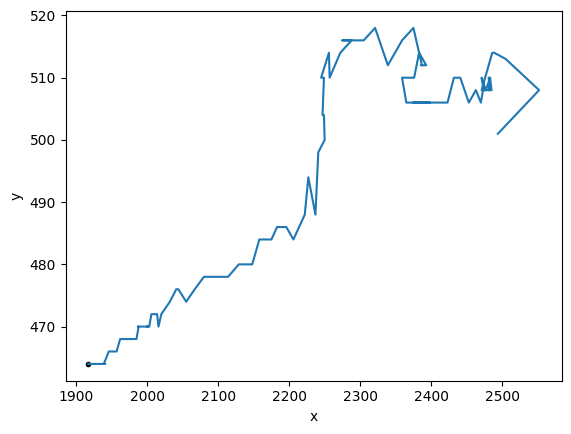

In [83]:
slic = slice(6,97)

plt.plot(centrox[6],centroy[6],'.k')
plt.plot(centrox[slic],centroy[slic])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

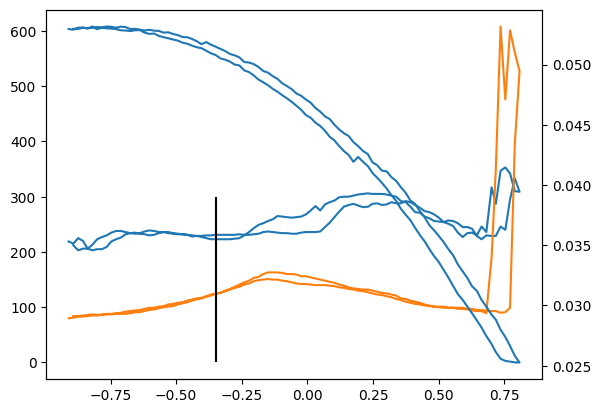

In [66]:
slic = slice(4,194)

ax1 = plt.subplot()
ax1.plot(tx_poses[slic],fwhmsx[slic])
ax1.plot(tx_poses[slic],fwhmsy[slic])
ax1.vlines(tx_poses[35],0,300,colors='k')

ax2 = ax1.twinx()
ax2.plot(tx_poses[slic],photcol[slic])

plt.show()

In [84]:
tx_poses[35]

-0.34903449999999997

In [85]:
np.argmax(np.sum(f['scan-0035/dvf2'],axis=0))

2129

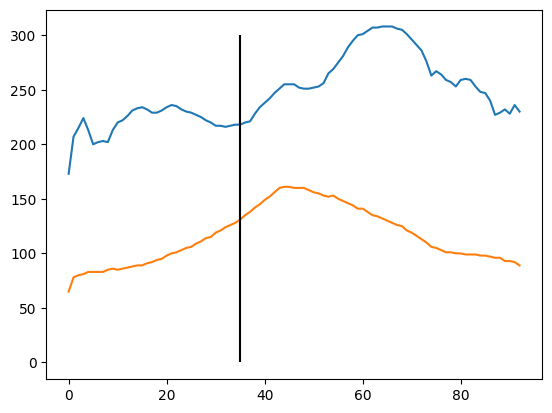

In [ ]:
plt.plot(fwhmsx[4:97])
plt.plot(fwhmsy[4:97])
plt.vlines(35,0,300,colors='k')


In [128]:
dict(f['scan-0035'].attrs)

{'tx_pos': -0.36189325}

In [129]:
CAX.mirror.tx_pos = -0.36189325

In [99]:
slit0 = {'top': 16.46-0.2, 'bottom': 34.6+0.2, 'left': 42.893359375+0.9, 'right': 46.866640625-0.9}

move_all(**slit0)

In [100]:
open_all_slits()

Anotações

Abrindo-se completamente a fenda, afastando o espelho do anel com Tx obtevemos o valor limite de posição para feixe sendo transmitido pela fenda:
tx = 0.80320475

Antes disso, em tx = 0.74319725, ainda há um mínimo sinal, ruidoso

Aproximando-se do anel, o limite de sinal de feixe, ruidoso, é para tx = -0.96501625

o limite inferior foi então tx = -1.00502125


O minimo inferior de movimentação do espelho em tx é -4.5